# GW detection

In [1]:
import h5py
import numpy as np
from matplotlib import pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format='retina'

In [2]:
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from astroML.utils import completeness_contamination

Data contain simulated gravitational-wave signals from merging black holes: spins of BHs, location, inclination, polarization, mass and snr

In [3]:
file = h5py.File('sample_2e7_design_precessing_higherordermodes_3detectors.h5', 'r')

In [4]:
file.keys()

<KeysViewHDF5 ['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'det', 'iota', 'mtot', 'psi', 'q', 'ra', 'snr', 'z']>

With these features and detectability based on the snr

In [5]:
N=100000 

y = np.array(file['det'][:N])
print(y.shape)

(100000,)


For visualization purposes, I will plot the total_mass vs snr of binaries using labels to show deteclable and non deteclable sources according to the threshold

In [6]:
mtot = file['mtot'][:N]
snr = file['snr'][:N]

I use the given labels

- det=0 if non detectable (SNR<12)
- det=1 if detectable (SNR>12)

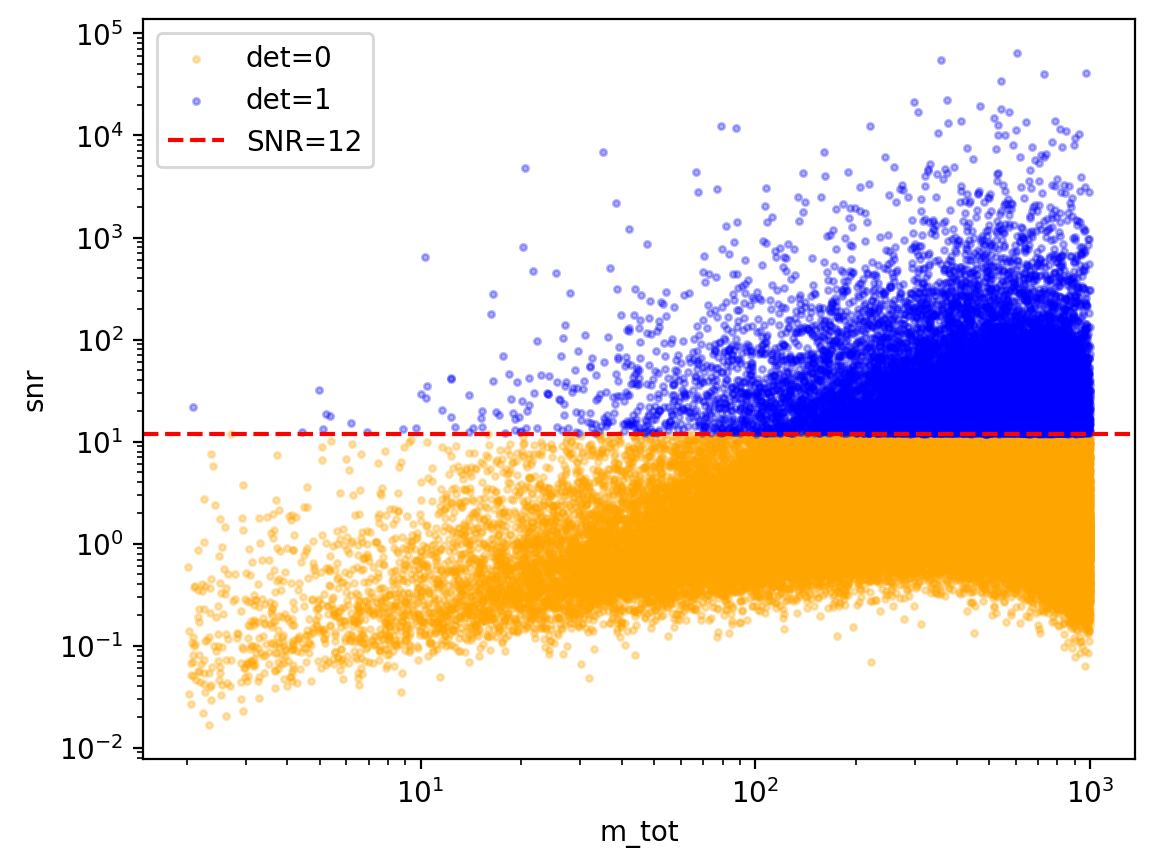

In [7]:
plt.scatter(mtot[y==0], snr[y==0], s=5, alpha=0.3, c='orange', label='det=0')
plt.scatter(mtot[y==1], snr[y==1], s=5, alpha=0.3, c='blue', label='det=1')
plt.axhline(12, ls='dashed',color='red', label='SNR=12')
plt.xlabel('m_tot')
plt.ylabel('snr')
plt.loglog()
plt.legend()
plt.show()

# DecisionTreeClassifier

let's try using a subset of features first (dec,mass,iota,psi,q,ra)

In [8]:
data_sub=[]

for i in ['dec','iota', 'mtot', 'psi','q', 'ra']:
    data_sub.append(file[i][:N])
    
X = np.array(data_sub).T

In [9]:
X_train, X_test, y_train, y_test, snr_train, snr_test = train_test_split(X, y, snr, test_size=0.3, random_state=42)

Visualize only the test set using given labels (to compare with the result of classification)

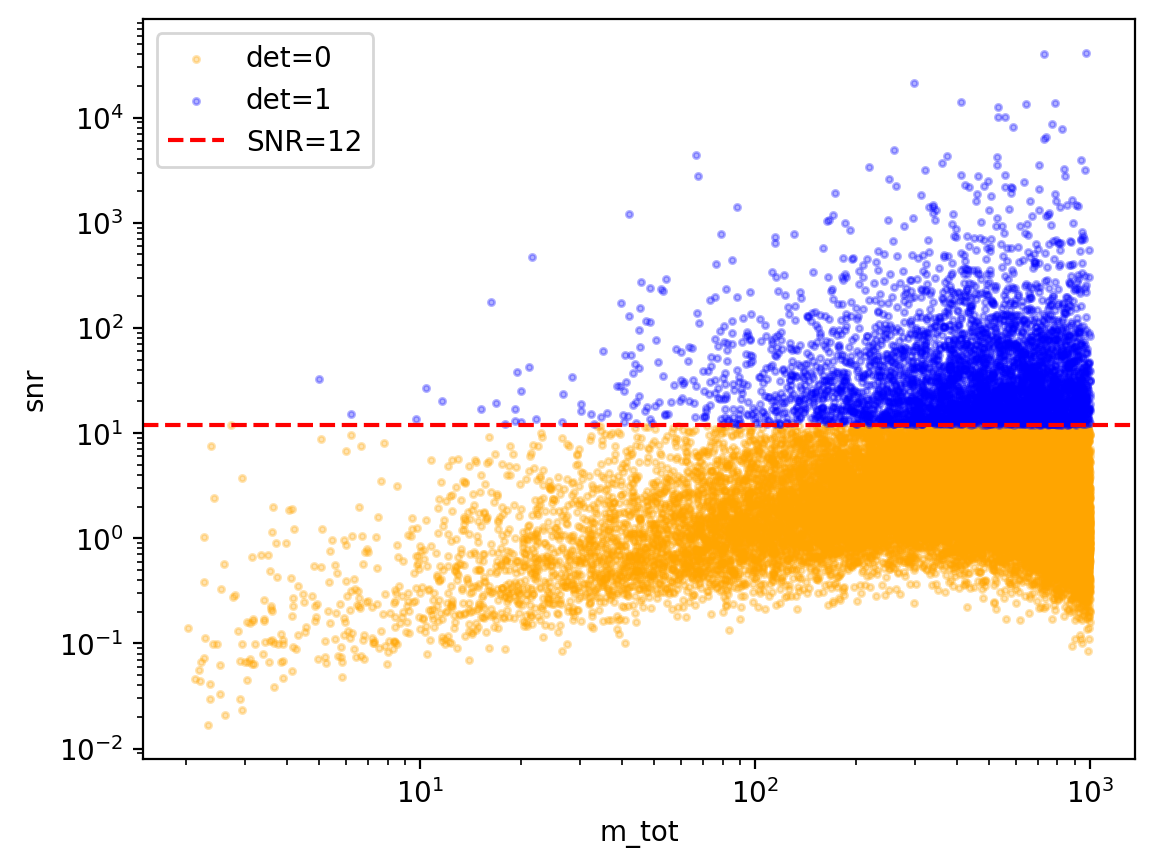

In [10]:
plt.scatter(X_test[:,2][y_test==0], snr_test[y_test==0], s=5, alpha=0.3, c='orange', label='det=0')
plt.scatter(X_test[:,2][y_test==1], snr_test[y_test==1], s=5, alpha=0.3, c='blue', label='det=1')
plt.axhline(12, ls='dashed',color='red', label='SNR=12')
plt.xlabel('m_tot')
plt.ylabel('snr')
plt.loglog()
plt.legend()
plt.show()

In [11]:
clf = DecisionTreeClassifier()
drange = np.arange(1,15)  

grid = GridSearchCV(clf, param_grid={'max_depth': drange}, cv=5, scoring='accuracy', n_jobs=-1) 
grid.fit(X_train, y_train)

best = grid.best_params_['max_depth']
print("best parameter choice:", best)

best parameter choice: 1


In [12]:
clf = DecisionTreeClassifier(random_state=0, max_depth=1, criterion='entropy')
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=1, random_state=0)

In [13]:
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:,1]

In [14]:
C = sklearn.metrics.confusion_matrix(y_test, y_pred)
print('Confusion matrix:')
print(C)

Confusion matrix:
[[25678     0]
 [ 4322     0]]


In [15]:
accuracy_dt = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy_dt)

Accuracy: 0.8559333333333333


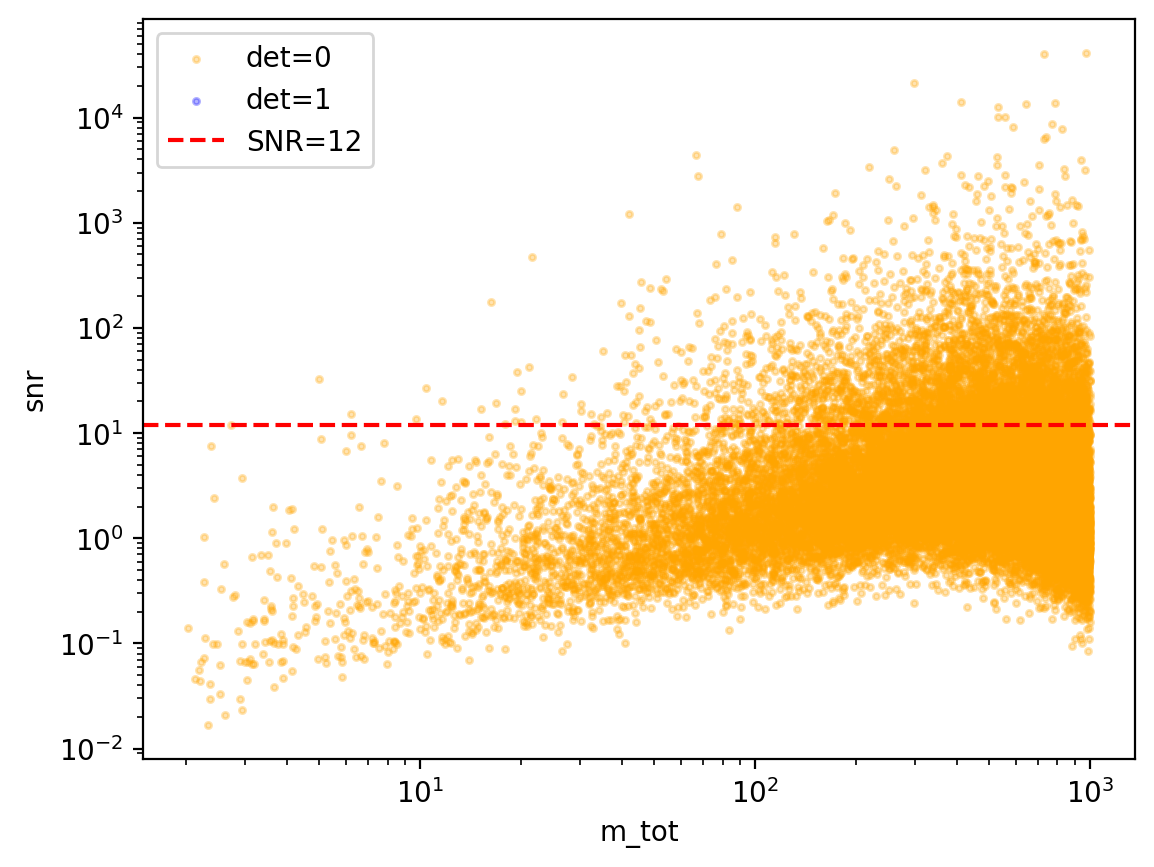

In [16]:
plt.scatter(X_test[:,2][y_pred==0], snr_test[y_pred==0], s=5, alpha=0.3, c='orange', label='det=0')
plt.scatter(X_test[:,2][y_pred==1], snr_test[y_pred==1], s=5, alpha=0.3, c='blue', label='det=1')
plt.axhline(12, ls='dashed',color='red', label='SNR=12')
plt.xlabel('m_tot')
plt.ylabel('snr')
plt.loglog()
plt.legend()
plt.show()

this doesn't look good

So let's use the full set of features

In [17]:
data=[]

for i in ['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'iota', 'mtot', 'psi', 'q', 'ra','z']:
    data.append(file[i][:N])
    
X = np.array(data).T

In [18]:
X_train, X_test, y_train, y_test, snr_train, snr_test= train_test_split(X, y, snr, test_size=0.3, random_state=42)

In [19]:
clf = DecisionTreeClassifier()
drange = np.arange(1,15)  

grid = GridSearchCV(clf, param_grid={'max_depth': drange}, cv=5, scoring='accuracy', n_jobs=-1) 
grid.fit(X_train, y_train)

best = grid.best_params_['max_depth']
print("best parameter choice:", best)

best parameter choice: 8


In [48]:
clf = DecisionTreeClassifier(random_state=0, max_depth=8, criterion='entropy')
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=8, random_state=0)

In [49]:
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:,1]

In [50]:
C = sklearn.metrics.confusion_matrix(y_test, y_pred)
print('Confusion matrix:')
print(C)

Confusion matrix:
[[25098   580]
 [  681  3641]]


In [51]:
accuracy_dt = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy_dt)

Accuracy: 0.9579666666666666


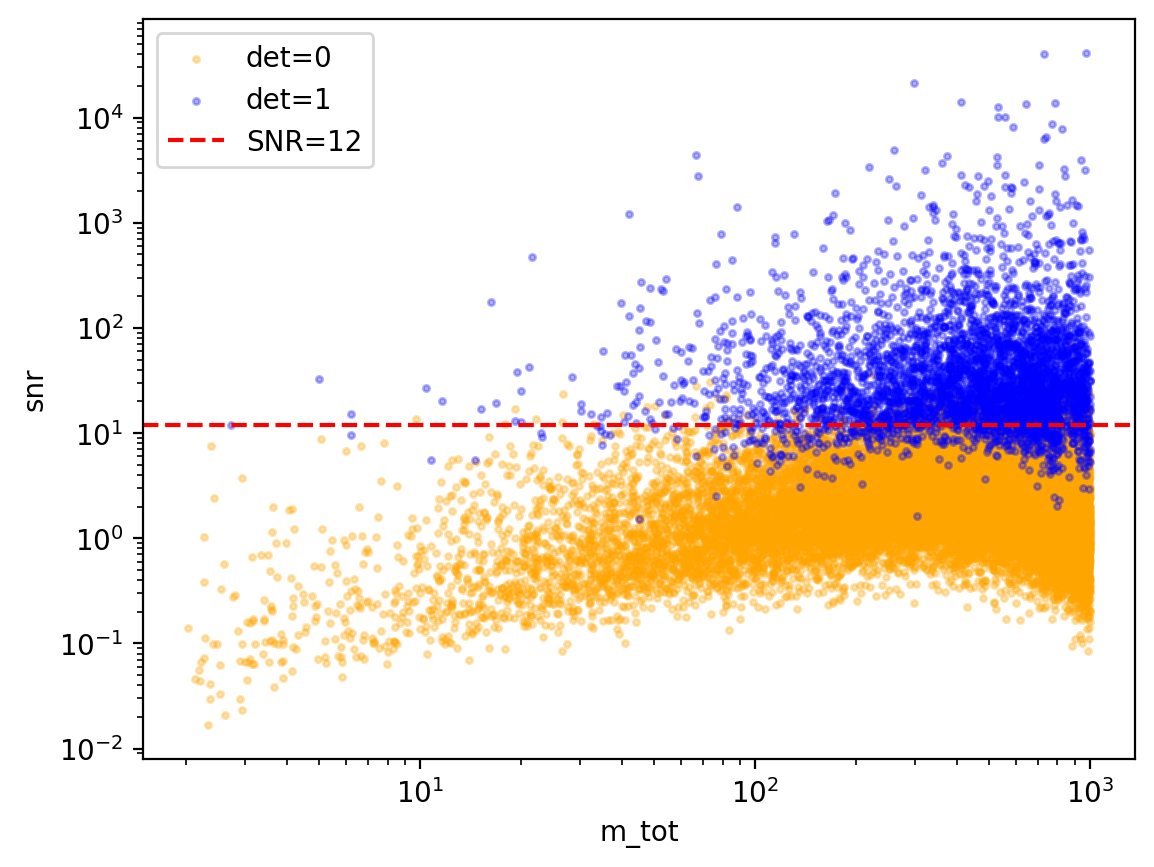

In [52]:
plt.scatter(X_test[:,8][y_pred==0], snr_test[y_pred==0], s=5, alpha=0.3, c='orange', label='det=0')
plt.scatter(X_test[:,8][y_pred==1], snr_test[y_pred==1], s=5, alpha=0.3, c='blue', label='det=1')
plt.axhline(12, ls='dashed',color='red', label='SNR=12')
plt.xlabel('m_tot')
plt.ylabel('snr')
plt.loglog()
plt.legend()
plt.show()

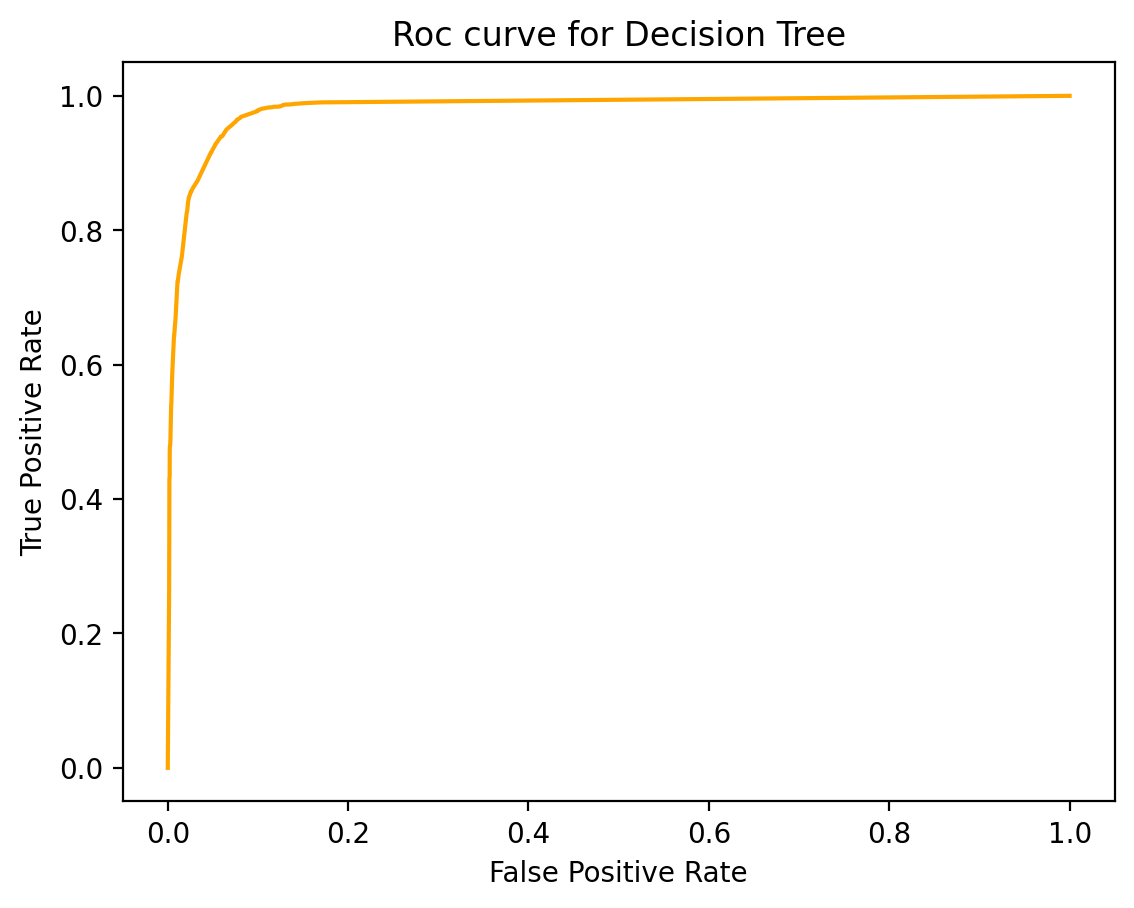

In [53]:
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test,y_prob)

plt.plot(fpr_dt, tpr_dt, color='orange')
plt.title('Roc curve for Decision Tree')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

In [54]:
comp_dt, cont_dt = completeness_contamination(y_pred, y_test)
print('Completeness test:', comp_dt)
print('Contamination test:', cont_dt)

Completeness test: 0.8424340583063397
Contamination test: 0.13740819710968966


try with different values of max_depth

In [27]:
completeness_test = []
contamination_test = []
completeness_train = []
contamination_train = []

max_dp = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

for M in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
    clf = DecisionTreeClassifier(random_state=1, max_depth=M,criterion='entropy')
    clf.fit(X_train, y_train) #fit on training set

    y_pred = clf.predict(X_test) #predict on test set
    comp_dt, cont_dt = completeness_contamination(y_pred, y_test)
    completeness_test.append(comp_dt)
    contamination_test.append(cont_dt)

    y_pred = clf.predict(X_train) #predict on training set
    comp_dt, cont_dt = completeness_contamination(y_pred, y_train)
    completeness_train.append(comp_dt)
    contamination_train.append(cont_dt)

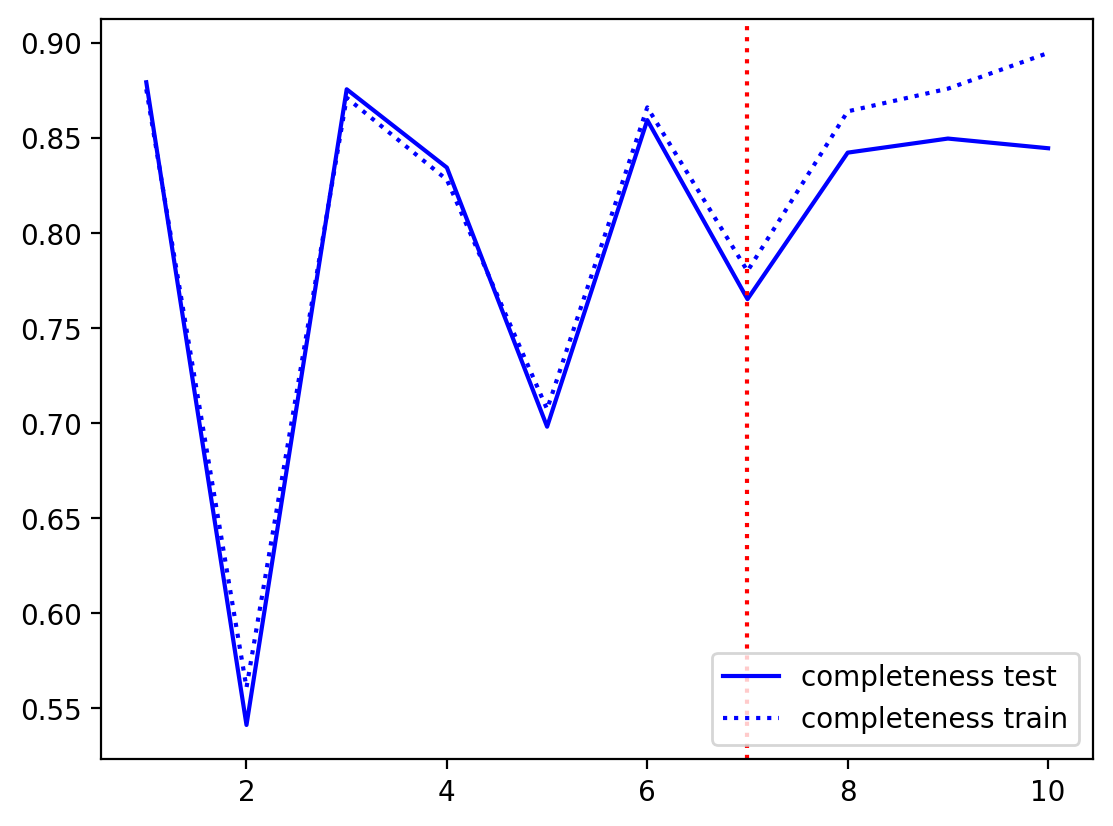

In [28]:
plt.plot(max_dp,completeness_test,label='completeness test',c='blue')
plt.plot(max_dp,completeness_train,label='completeness train',c='blue',ls='dotted')

plt.axvline(7, color='red', ls='dotted')
plt.legend();

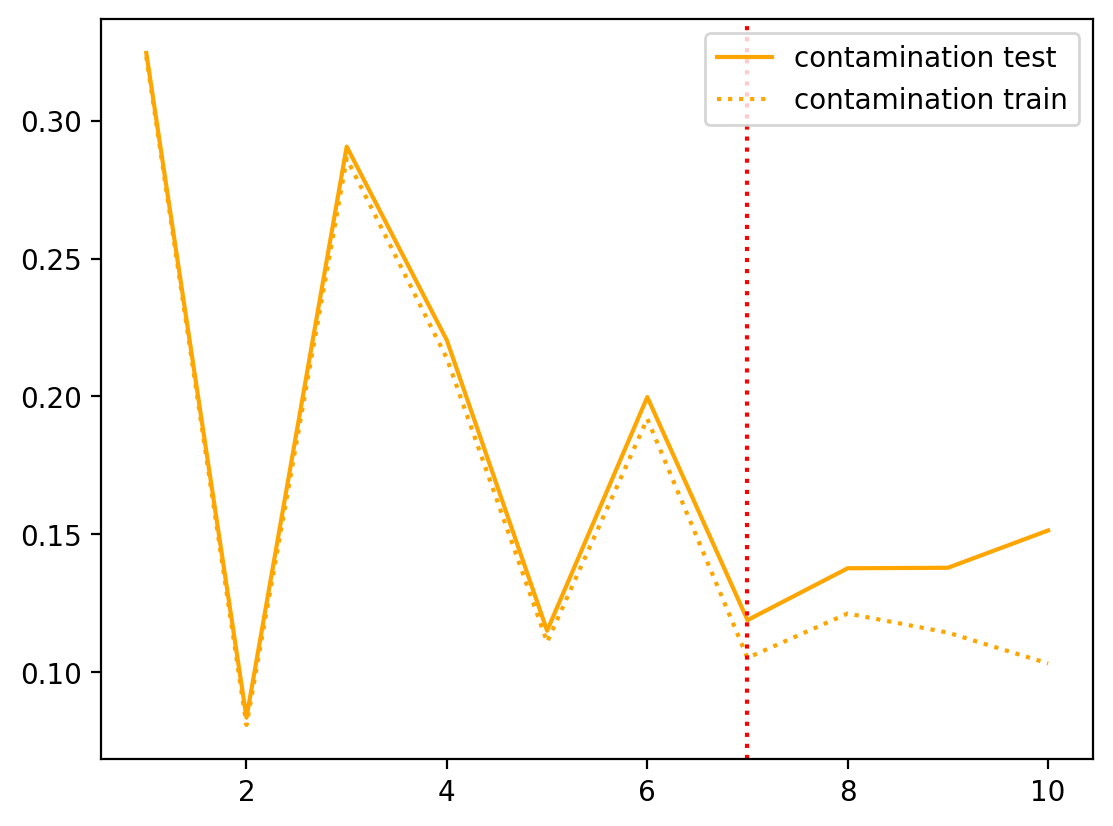

In [29]:
plt.plot(max_dp,contamination_test,label='contamination test',c='orange')
plt.plot(max_dp,contamination_train,label='contamination train',c='orange',ls='dotted')

plt.axvline(7, color='red', ls='dotted')
plt.legend();

when max_depth=7, overfitting begins 

In [56]:
clf = DecisionTreeClassifier(random_state=0, max_depth=7, criterion='entropy')
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [57]:
C = sklearn.metrics.confusion_matrix(y_test, y_pred)
print('Confusion matrix:')
print(C)

Confusion matrix:
[[25233   445]
 [ 1015  3307]]


In [58]:
accuracy_dt = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy_dt)

Accuracy: 0.9513333333333334


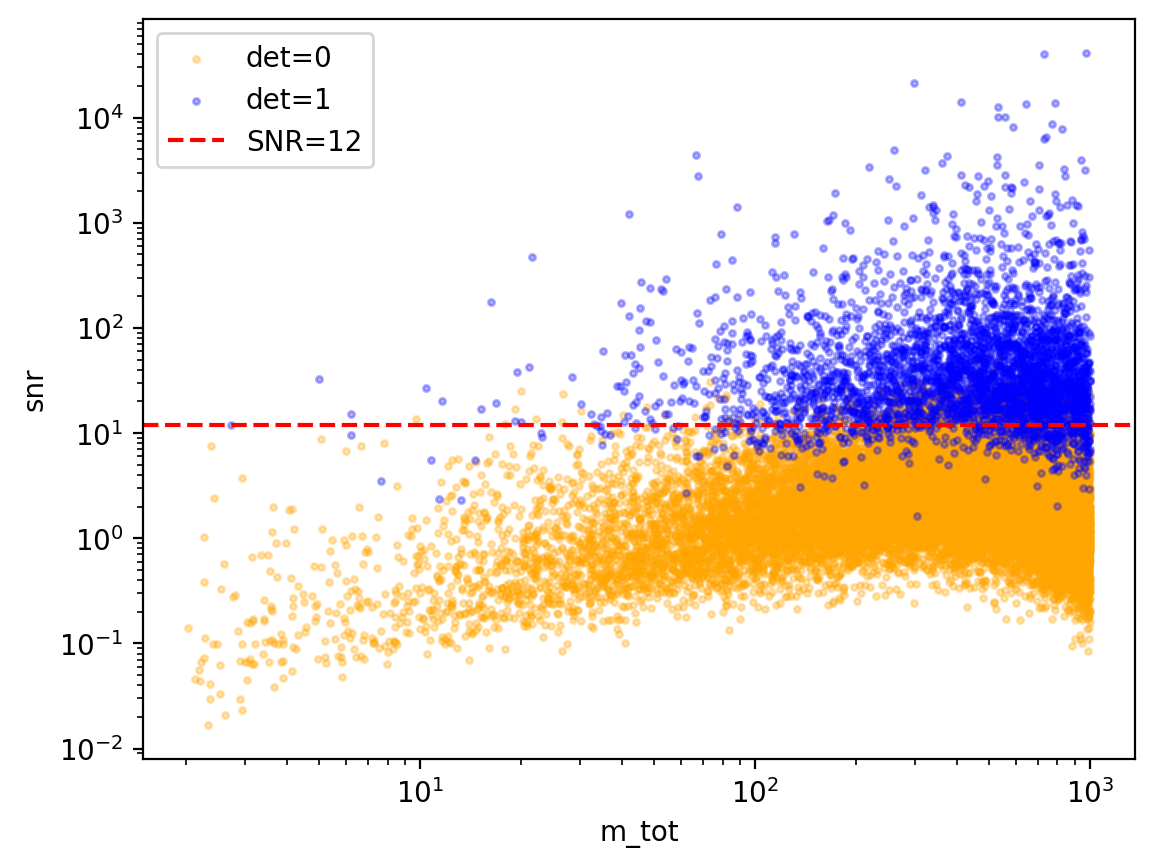

In [59]:
plt.scatter(X_test[:,8][y_pred==0], snr_test[y_pred==0], s=5, alpha=0.3, c='orange', label='det=0')
plt.scatter(X_test[:,8][y_pred==1], snr_test[y_pred==1], s=5, alpha=0.3, c='blue', label='det=1')
plt.axhline(12, ls='dashed',color='red', label='SNR=12')
plt.xlabel('m_tot')
plt.ylabel('snr')
plt.loglog()
plt.legend()
plt.show()

# RandomForestClassifier

In [34]:
clf = RandomForestClassifier(n_estimators=200, max_depth=7, criterion='entropy',n_jobs=-1)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [35]:
comp_dt, cont_dt = completeness_contamination(y_pred, y_test)
print('Completeness test:', comp_dt)
print('Contamination test:', cont_dt)

Completeness test: 0.8056455344747802
Contamination test: 0.10118740320082602


In [36]:
C = sklearn.metrics.confusion_matrix(y_test, y_pred)
print('Confusion matrix:')
print(C)

Confusion matrix:
[[25286   392]
 [  840  3482]]


In [37]:
accuracy_rf = accuracy_score(y_test, y_pred)
print(accuracy_rf)

0.9589333333333333


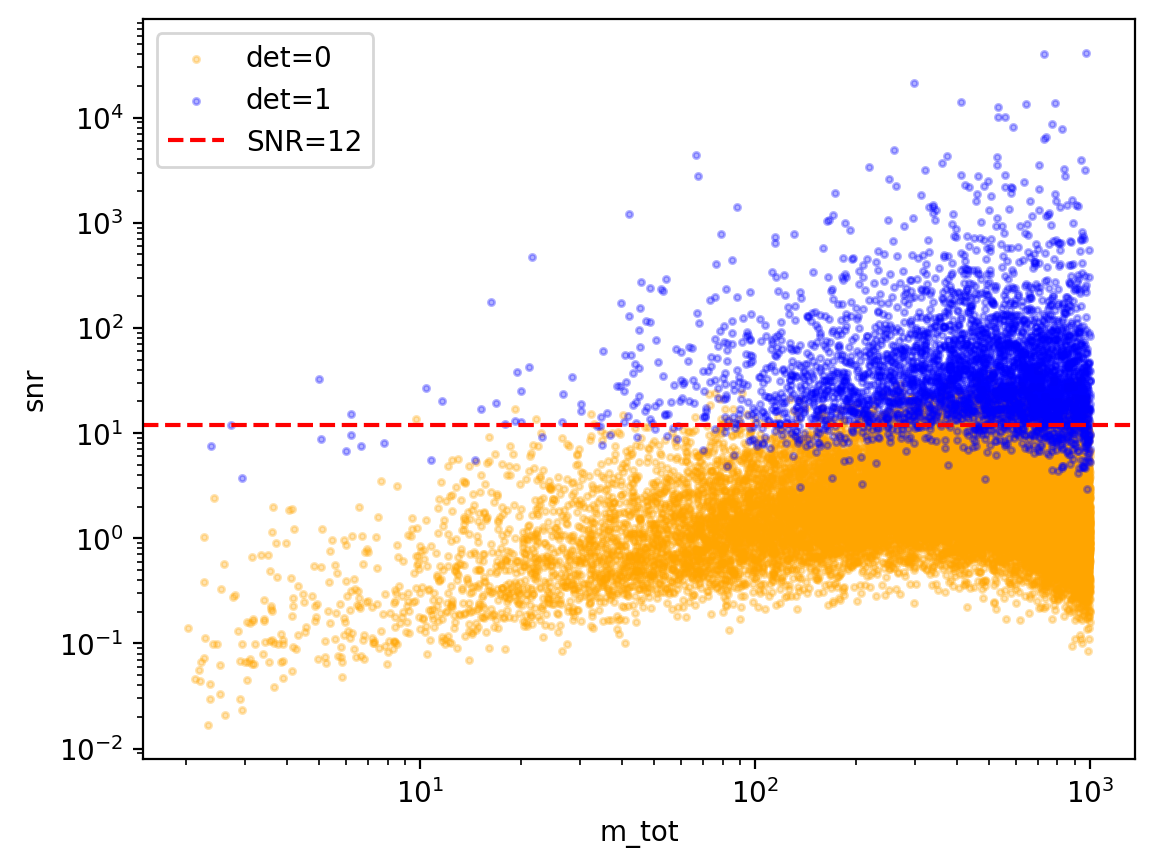

In [38]:
plt.scatter(X_test[:,8][y_pred==0], snr_test[y_pred==0], s=5, alpha=0.3, c='orange', label='det=0')
plt.scatter(X_test[:,8][y_pred==1], snr_test[y_pred==1], s=5, alpha=0.3, c='blue', label='det=1')
plt.axhline(12, ls='dashed',color='red', label='SNR=12')
plt.xlabel('m_tot')
plt.ylabel('snr')
plt.loglog()
plt.legend()
plt.show()

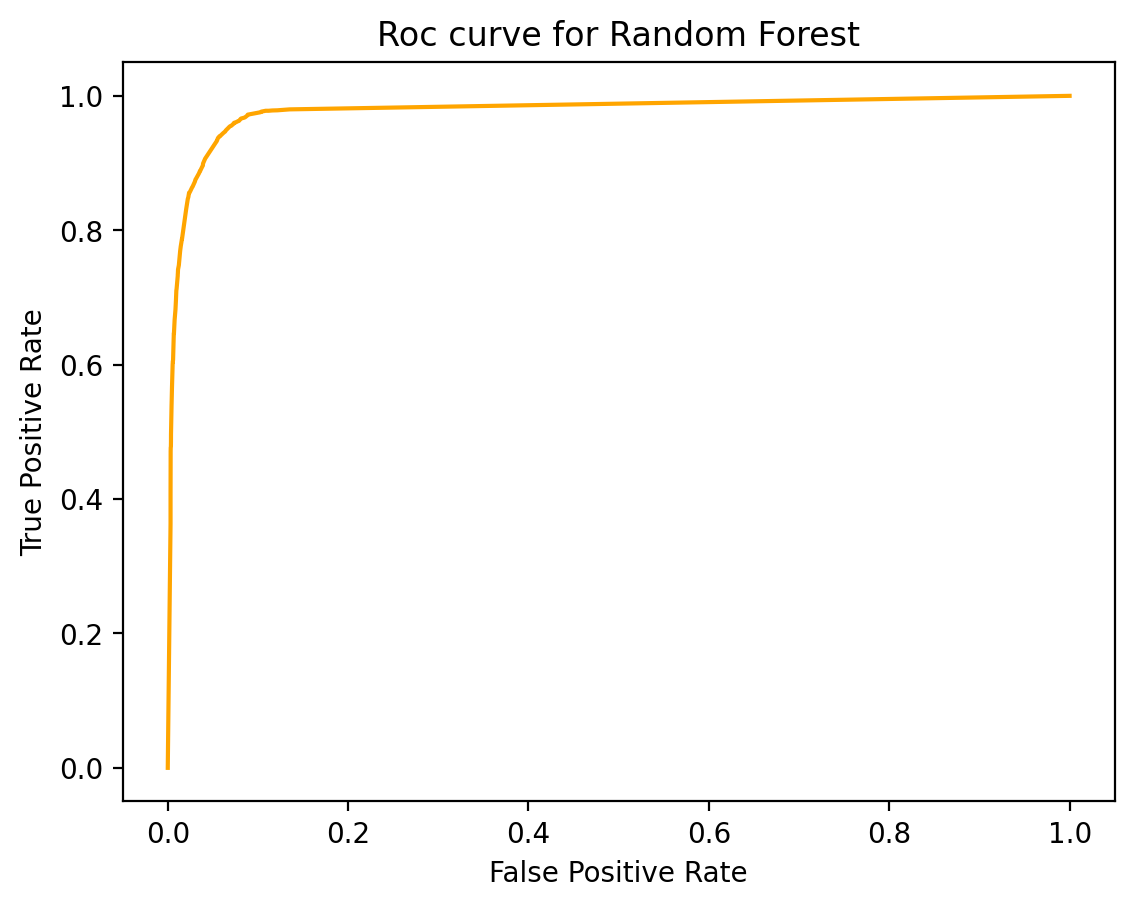

In [39]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test,y_prob)

plt.plot(fpr_dt, tpr_dt, color='orange')
plt.title('Roc curve for Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

# GradientBoostingClassifier

In [40]:
gbc = GradientBoostingClassifier(n_estimators=200, max_depth=7, random_state=0)
gbc.fit(X_train, y_train)

GradientBoostingClassifier(max_depth=7, n_estimators=200, random_state=0)

In [41]:
y_pred = gbc.predict(X_test)
y_prob = gbc.predict_proba(X_test)[:,1]

In [42]:
comp_dt, cont_dt = completeness_contamination(y_pred, y_test)
print('Completeness test:', comp_dt)
print('Contamination test:', cont_dt)

Completeness test: 0.9018972697825081
Contamination test: 0.07300832342449465


In [43]:
C = sklearn.metrics.confusion_matrix(y_test, y_pred)
print('Confusion matrix:')
print(C)

Confusion matrix:
[[25371   307]
 [  424  3898]]


In [44]:
accuracy_gb = accuracy_score(y_test, y_pred)
print(accuracy_gb)

0.9756333333333334


Higher accuracy!

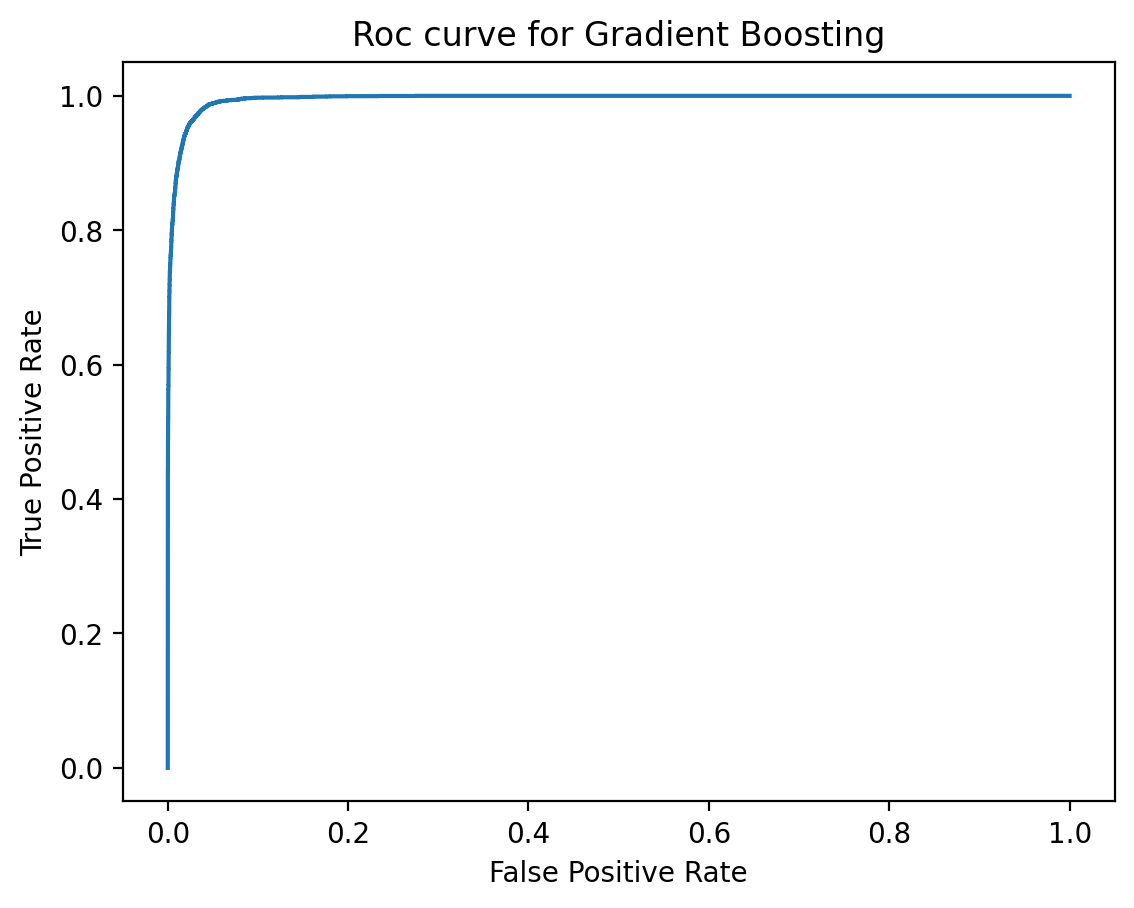

In [45]:
fpr_gb, tpr_gb, thresholds_gb = roc_curve(y_test,y_prob)

plt.plot(fpr_gb, tpr_gb)
plt.title('Roc curve for Gradient Boosting')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

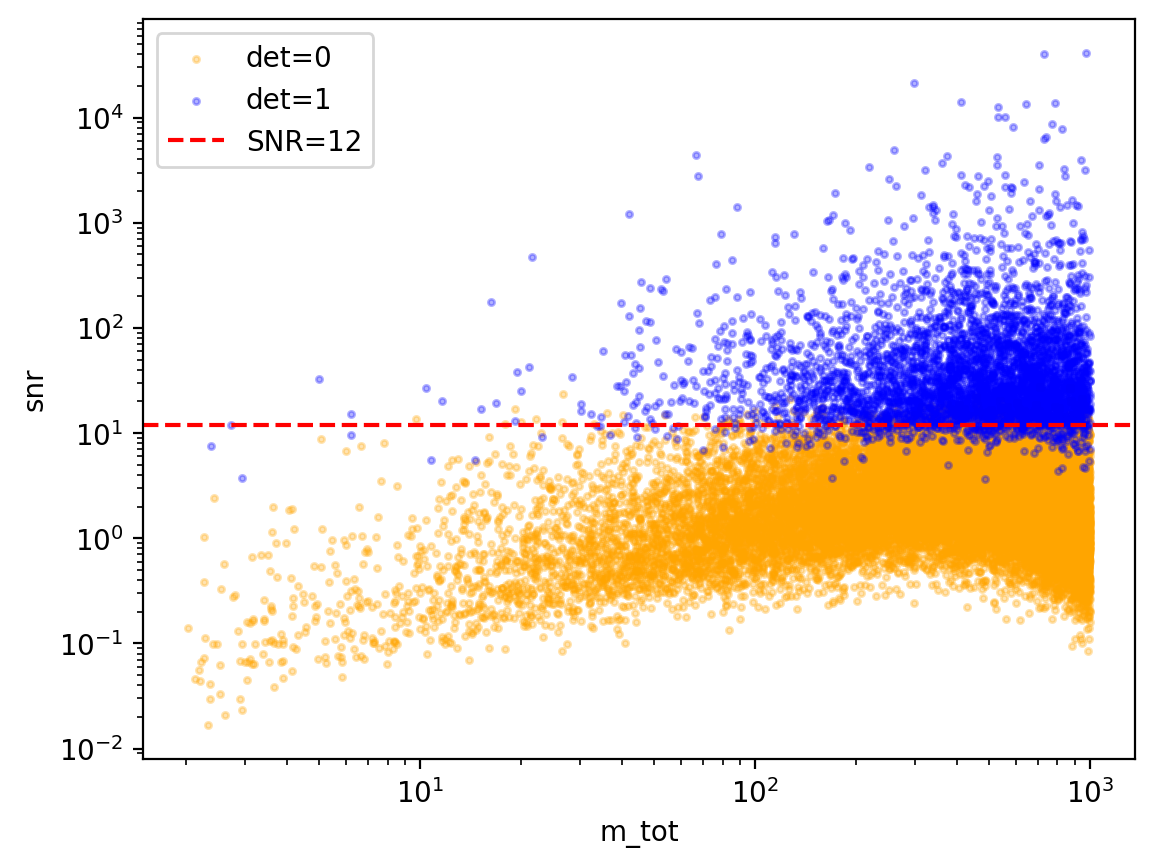

In [46]:
plt.scatter(X_test[:,8][y_pred==0], snr_test[y_pred==0], s=5, alpha=0.3, c='orange', label='det=0')
plt.scatter(X_test[:,8][y_pred==1], snr_test[y_pred==1], s=5, alpha=0.3, c='blue', label='det=1')
plt.axhline(12, ls='dashed',color='red', label='SNR=12')
plt.xlabel('m_tot')
plt.ylabel('snr')
plt.loglog()
plt.legend()
plt.show()

In [60]:
print('Accuracies')
print('DecisionTree:', accuracy_dt)
print('RandomForest:', accuracy_rf)
print('GradientBoosting:', accuracy_gb)

Accuracies
DecisionTree: 0.9513333333333334
RandomForest: 0.9589333333333333
GradientBoosting: 0.9756333333333334
